In [ ]:
import pandana as pdna
import osmium
from osmium import filter, osm, geom
from shapely import wkt
import geopandas as gpd
import pandas as pd

#################### Collect all amenities ####################
data= "../../denmark-260208.osm.pbf"
fp = osmium.FileProcessor(data).with_areas() \
    .with_filter(filter.EntityFilter(osm.NODE | osm.AREA))\
    .with_filter(filter.KeyFilter("amenity")
)

fab = geom.WKTFactory()

def to_points(o):
    if o.is_node():
        point = wkt.loads(fab.create_point(o))
    elif o.is_area():
        poly = wkt.loads(fab.create_multipolygon(o))
        point = poly.centroid
    else:
        raise AssertionError(f"Unreachable: {o}")

    return point, o.tags.get("amenity")

points, names = map(list, zip(*[to_points(obj) for obj in fp]))

gdf = gpd.GeoDataFrame(
    {"amenity": names},
    geometry=points,
    crs="EPSG:4326"
)
print(gdf.head())

#################### Calculate ####################

network = pdna.Network.from_hdf5("denmark.backup")

WALKING_SPEED_KMPH = 4
MAX_WALKING_TIME_MIN = 15
max_distance = WALKING_SPEED_KMPH * 1000 / 60 * MAX_WALKING_TIME_MIN  # meters

print("precumputing end")

categories = {
    "education": {"amenity": ["school", "university"]},
    "health": {"amenity": ["hospital", "clinic"]},
    "grocery": {"shop": ["supermarket", "convenience"]},
    "leisure": {"leisure": ["park", "playground"]},
    "culture": {"amenity": ["theatre", "museum"]},
}

print("loop begin")
poi_distances = {}

for category_name, tag_filter in categories.items():

    # filter gdf for that category
    if "amenity" not in tag_filter:
        continue
    
    subset = gdf[gdf["amenity"].isin(tag_filter["amenity"])]    

    # set ALL POIs at once
    network.set_pois(
        category_name,
        max_distance,
        1,
        subset.geometry.x,
        subset.geometry.y
    )

    # compute distances ONCE
    d = network.nearest_pois(
        max_distance,
        category_name,
        num_pois=1
    ).iloc[:, 0]

    poi_distances[category_name] = d

print("loop end")
poi_distances = pd.DataFrame(poi_distances)

print("pandas begin")
# Binary reachability per category (1 if reachable within 15 min, else 0)
poi_distances = poi_distances.reindex(columns=categories.keys())
reachable = (poi_distances <= max_distance).fillna(False).astype(int)
access_score = reachable.sum(axis=1)
print("pandas end")

result = pd.concat([reachable, access_score.rename("access_score")], axis=1)
print(result.head())

            amenity                   geometry
0  parking_entrance  POINT (12.28014 55.65207)
1  parking_entrance  POINT (12.27711 55.65166)
2        restaurant    POINT (8.1713 55.72059)
3    ferry_terminal  POINT (12.69152 56.04331)
4         recycling  POINT (12.63625 55.65714)
precumputing end
loop begin
loop end
pandas begin
pandas end
   education  health  grocery  leisure  culture  access_score
0          1       1        0        0        1             3
1          1       1        0        0        1             3
2          1       1        0        0        1             3
3          1       1        0        0        1             3
4          1       1        0        0        1             3


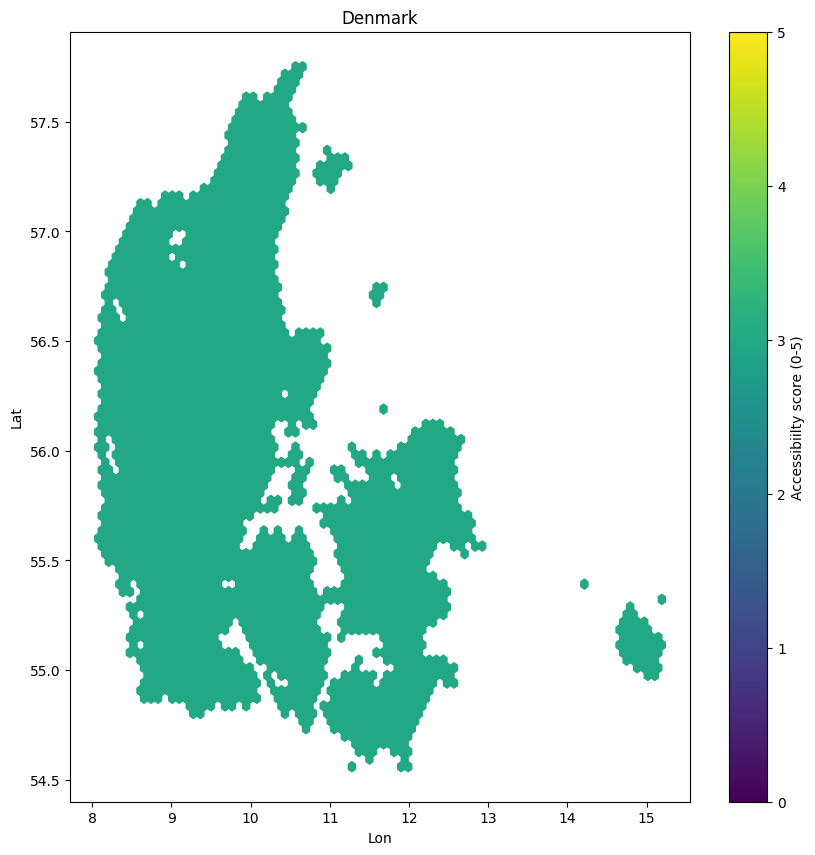

In [ ]:
import matplotlib.pyplot as plt
nodes_df = network.nodes_df

plot_data = nodes_df.join(result)
x = plot_data["x"]
y = plot_data["y"]
z = plot_data["access_score"]
plot, ax = plt.subplots(figsize=(10, 10))
scatter = ax.hexbin(x, y, C=z, gridsize=80, cmap="viridis", vmin=0, vmax=5)
ax.set_title("Denmark")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Accessibiilty score (0-5)")
plt.show()